# Bank Telemarketing Prediction Models

This notebook trains two machine learning models on the bank-full-transformed dataset to predict the target variable 'y' (whether a customer will subscribe to a term deposit).

## 1. Load Libraries

In [59]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, roc_curve, confusion_matrix
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)

## 2. Load and Inspect Dataset

In [60]:
df = pd.read_csv('data_firsts_final.csv')

print("Dataset shape:", df.shape)
print("\nSummary statistics:")
print(df.describe())
print("\nClass distribution for target 'y':")
print(df['y'].value_counts())
print("\nClass balance:")
print(df['y'].value_counts(normalize=True))

Dataset shape: (36954, 30)

Summary statistics:
                day   balance_log  month_encoded  campaign_log
count  36954.000000  36954.000000   36954.000000  36954.000000
mean      16.145424      9.114232       5.214158      1.188230
std        8.372554      0.212155       2.219061      0.529437
min        1.000000      0.693147       0.000000      0.693147
25%        9.000000      8.996652       4.000000      0.693147
50%       17.000000      9.040145       5.000000      1.098612
75%       22.000000      9.146228       7.000000      1.386294
max       31.000000     11.609580      11.000000      4.158883

Class distribution for target 'y':
y
False    33570
True      3384
Name: count, dtype: int64

Class balance:
y
False    0.908427
True     0.091573
Name: proportion, dtype: float64


## 3. Preprocess Features and Target

In [61]:
X = df.drop('y', axis=1)
y = df['y'].astype(int) 

bool_cols = X.select_dtypes(include=['bool']).columns
X[bool_cols] = X[bool_cols].astype(int)

cat_cols = X.select_dtypes(include=['object']).columns
if len(cat_cols) > 0:
    X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)
print("Training target distribution:")
print(y_train.value_counts(normalize=True))
print("Test target distribution:")
print(y_test.value_counts(normalize=True))

Training set shape: (29563, 29)
Test set shape: (7391, 29)
Training target distribution:
y
0    0.908433
1    0.091567
Name: proportion, dtype: float64
Test target distribution:
y
0    0.908402
1    0.091598
Name: proportion, dtype: float64


## 4. Train Logistic Regression

In [62]:
lr_model = LogisticRegression(random_state=42, max_iter=5000)
lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)
lr_pred_proba = lr_model.predict_proba(X_test)[:, 1]

lr_accuracy = accuracy_score(y_test, lr_pred)
lr_roc_auc = roc_auc_score(y_test, lr_pred_proba)
lr_report = classification_report(y_test, lr_pred, output_dict=True)

print("Logistic Regression Results:")
print(f"Accuracy: {lr_accuracy:.4f}")
print(f"ROC AUC: {lr_roc_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, lr_pred))

Logistic Regression Results:
Accuracy: 0.9083
ROC AUC: 0.6951

Classification Report:
              precision    recall  f1-score   support

           0       0.91      1.00      0.95      6714
           1       0.40      0.00      0.01       677

    accuracy                           0.91      7391
   macro avg       0.65      0.50      0.48      7391
weighted avg       0.86      0.91      0.87      7391



## 5. Train XGBoost

In [63]:
xgb_model = xgb.XGBClassifier(random_state=42, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)
xgb_pred_proba = xgb_model.predict_proba(X_test)[:, 1]

xgb_accuracy = accuracy_score(y_test, xgb_pred)
xgb_roc_auc = roc_auc_score(y_test, xgb_pred_proba)
xgb_report = classification_report(y_test, xgb_pred, output_dict=True)

print("XGBoost Results:")
print(f"Accuracy: {xgb_accuracy:.4f}")
print(f"ROC AUC: {xgb_roc_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, xgb_pred))

xgb_feature_importance = xgb_model.feature_importances_

XGBoost Results:
Accuracy: 0.9091
ROC AUC: 0.7291

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.99      0.95      6714
           1       0.51      0.14      0.23       677

    accuracy                           0.91      7391
   macro avg       0.72      0.57      0.59      7391
weighted avg       0.88      0.91      0.89      7391



## 6. Evaluate Models

Models Comparison:
                 Model  Accuracy   ROC AUC  Precision    Recall  F1-Score
0  Logistic Regression  0.908267  0.695077   0.400000  0.002954  0.005865
1              XGBoost  0.909079  0.729135   0.513089  0.144756  0.225806


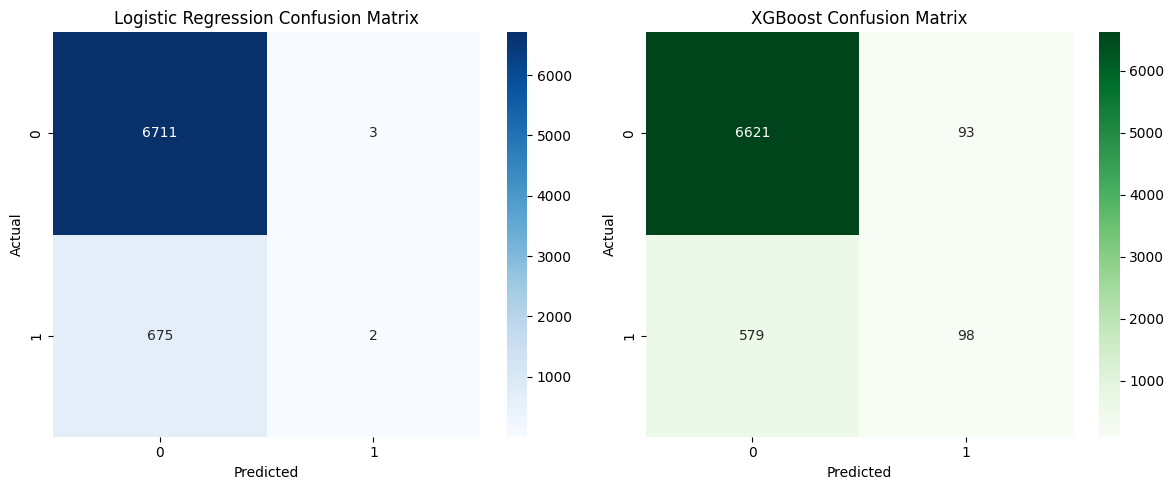

In [64]:
models_comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'XGBoost'],
    'Accuracy': [lr_accuracy, xgb_accuracy],
    'ROC AUC': [lr_roc_auc, xgb_roc_auc],
    'Precision': [lr_report['1']['precision'], xgb_report['1']['precision']],
    'Recall': [lr_report['1']['recall'], xgb_report['1']['recall']],
    'F1-Score': [lr_report['1']['f1-score'], xgb_report['1']['f1-score']]
})

print("Models Comparison:")
print(models_comparison)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_lr = confusion_matrix(y_test, lr_pred)
sns.heatmap(cm_lr, annot=True, fmt='d', ax=axes[0], cmap='Blues')
axes[0].set_title('Logistic Regression Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

cm_xgb = confusion_matrix(y_test, xgb_pred)
sns.heatmap(cm_xgb, annot=True, fmt='d', ax=axes[1], cmap='Greens')
axes[1].set_title('XGBoost Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

## 7. Visualize Results

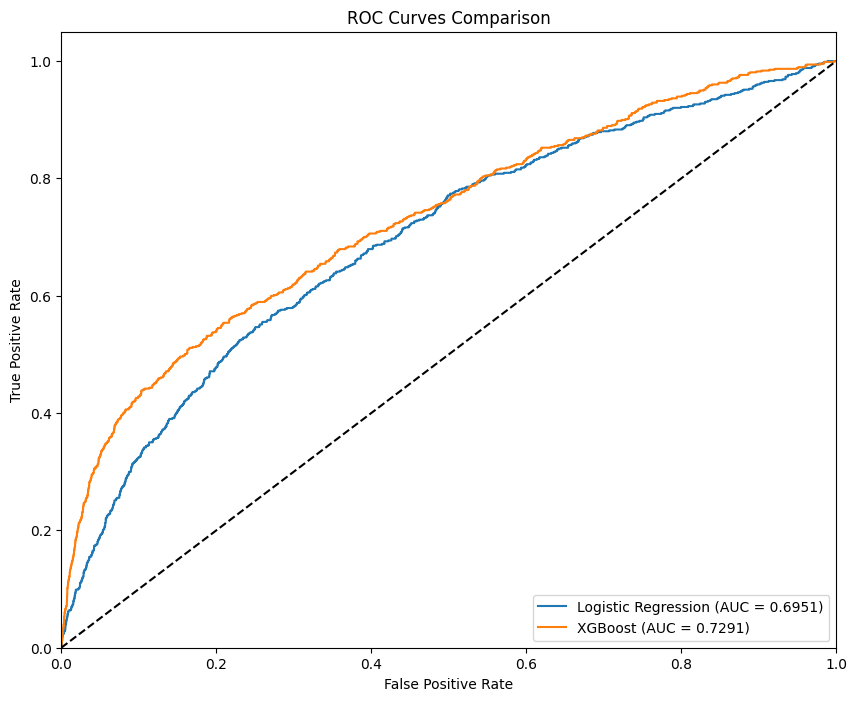

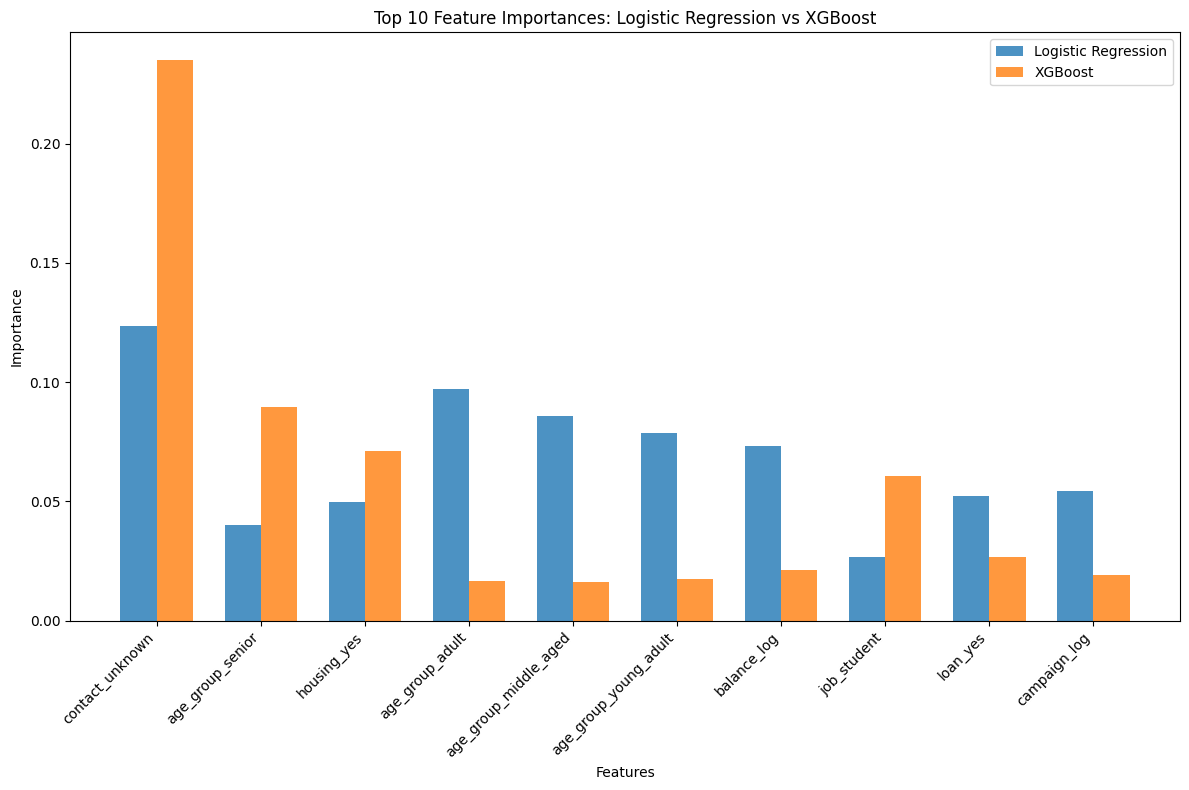

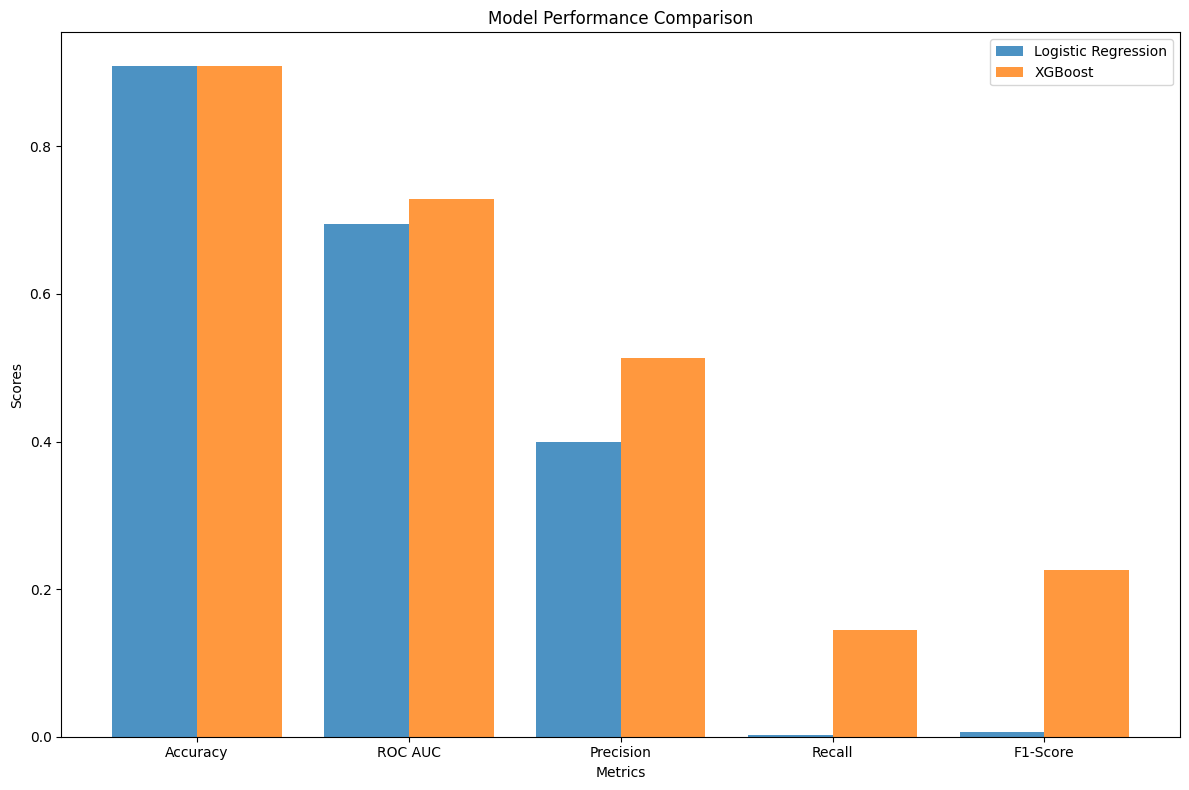


---
Training and evaluating on balanced target variable y
Nach Balancierung: Klassenverteilung (train):
y
0    26856
1    26856
Name: count, dtype: int64

Logistic Regression (balanced y) metrics:
Accuracy: 0.6337, ROC AUC: 0.6934
              precision    recall  f1-score   support

           0       0.95      0.63      0.76      6714
           1       0.15      0.65      0.25       677

    accuracy                           0.63      7391
   macro avg       0.55      0.64      0.50      7391
weighted avg       0.87      0.63      0.71      7391

XGBoost (balanced y) metrics:
Accuracy: 0.8079, ROC AUC: 0.7182
              precision    recall  f1-score   support

           0       0.94      0.84      0.89      6714
           1       0.23      0.48      0.31       677

    accuracy                           0.81      7391
   macro avg       0.59      0.66      0.60      7391
weighted avg       0.88      0.81      0.84      7391


Balanced models comparison:
                     

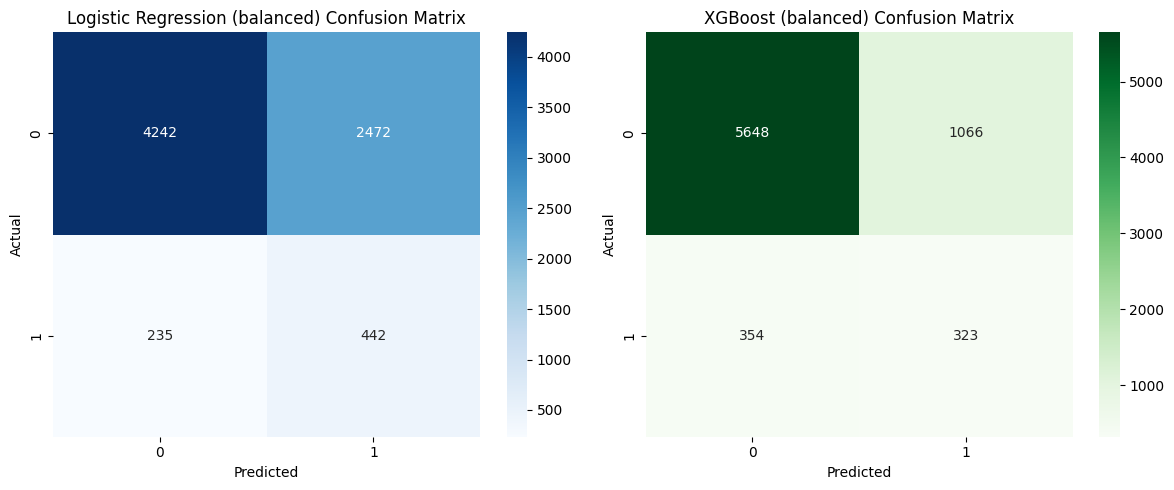

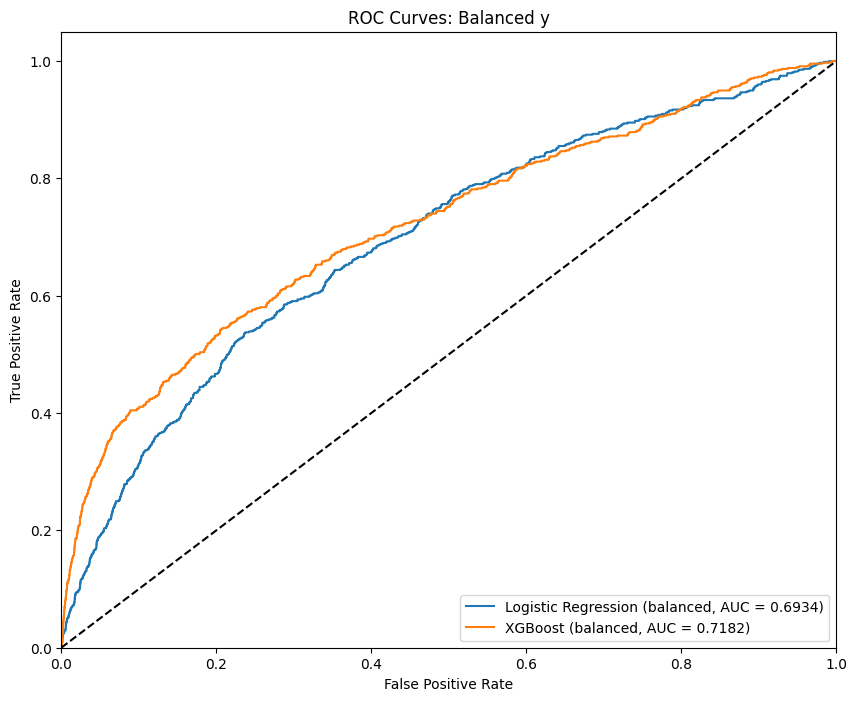

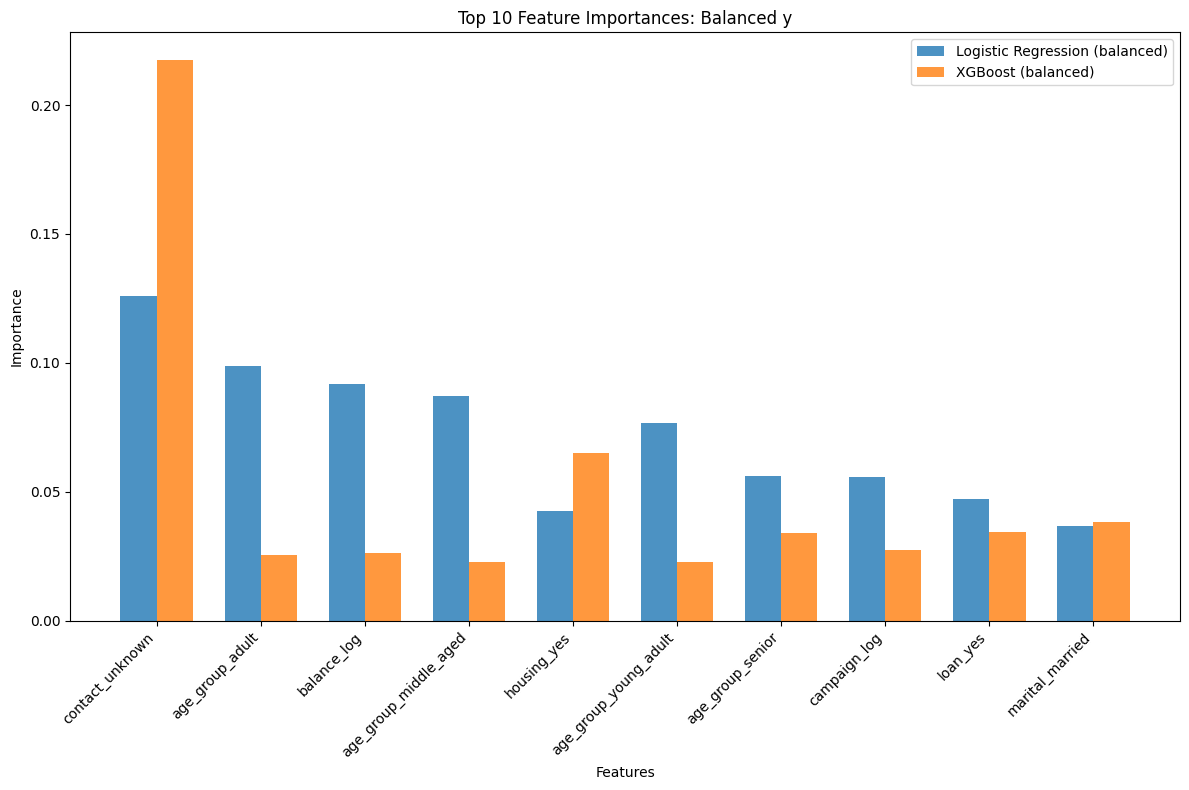

In [65]:
plt.figure(figsize=(10, 8))

fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_pred_proba)
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {lr_roc_auc:.4f})')

fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_pred_proba)
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {xgb_roc_auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves Comparison')
plt.legend(loc="lower right")
plt.show()

feature_names = X.columns
lr_feature_importance = np.abs(lr_model.coef_[0]) / np.sum(np.abs(lr_model.coef_[0]))
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Logistic Regression': lr_feature_importance,
    'XGBoost': xgb_feature_importance
})

importance_df['Average'] = (importance_df['Logistic Regression'] + importance_df['XGBoost']) / 2
top_features = importance_df.nlargest(10, 'Average')

plt.figure(figsize=(12, 8))
x = np.arange(len(top_features))
width = 0.35

plt.bar(x - width/2, top_features['Logistic Regression'], width, label='Logistic Regression', alpha=0.8)
plt.bar(x + width/2, top_features['XGBoost'], width, label='XGBoost', alpha=0.8)

plt.xlabel('Features')
plt.ylabel('Importance')
plt.title('Top 10 Feature Importances: Logistic Regression vs XGBoost')
plt.xticks(x, top_features['Feature'], rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

metrics = ['Accuracy', 'ROC AUC', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(metrics))
width = 0.4

fig, ax = plt.subplots(figsize=(12, 8))
rects1 = ax.bar(x - width/2, models_comparison.loc[0, metrics], width, label='Logistic Regression', alpha=0.8)
rects2 = ax.bar(x + width/2, models_comparison.loc[1, metrics], width, label='XGBoost', alpha=0.8)

ax.set_xlabel('Metrics')
ax.set_ylabel('Scores')
ax.set_title('Model Performance Comparison')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()

plt.tight_layout()
plt.show()

print('\n---\nTraining and evaluating on balanced target variable y')

from sklearn.utils import resample

train_bal = pd.concat([X_train, y_train], axis=1)
majority = train_bal[train_bal['y'] == 0]
minority = train_bal[train_bal['y'] == 1]
minority_upsampled = resample(minority, replace=True, n_samples=len(majority), random_state=42)

train_balanced = pd.concat([majority, minority_upsampled])
X_train_bal = train_balanced.drop('y', axis=1)
y_train_bal = train_balanced['y']

print('Nach Balancierung: Klassenverteilung (train):')
print(y_train_bal.value_counts())

lr_model_bal = LogisticRegression(random_state=42, max_iter=5000)
lr_model_bal.fit(X_train_bal, y_train_bal)

xgb_model_bal = xgb.XGBClassifier(random_state=42, eval_metric='logloss')
xgb_model_bal.fit(X_train_bal, y_train_bal)

lr_pred_bal = lr_model_bal.predict(X_test)
lr_pred_proba_bal = lr_model_bal.predict_proba(X_test)[:, 1]

xgb_pred_bal = xgb_model_bal.predict(X_test)
xgb_pred_proba_bal = xgb_model_bal.predict_proba(X_test)[:, 1]

lr_accuracy_bal = accuracy_score(y_test, lr_pred_bal)
lr_roc_auc_bal = roc_auc_score(y_test, lr_pred_proba_bal)
lr_report_bal = classification_report(y_test, lr_pred_bal, output_dict=True)

xgb_accuracy_bal = accuracy_score(y_test, xgb_pred_bal)
xgb_roc_auc_bal = roc_auc_score(y_test, xgb_pred_proba_bal)
xgb_report_bal = classification_report(y_test, xgb_pred_bal, output_dict=True)

print('\nLogistic Regression (balanced y) metrics:')
print(f'Accuracy: {lr_accuracy_bal:.4f}, ROC AUC: {lr_roc_auc_bal:.4f}')
print(classification_report(y_test, lr_pred_bal))

print('XGBoost (balanced y) metrics:')
print(f'Accuracy: {xgb_accuracy_bal:.4f}, ROC AUC: {xgb_roc_auc_bal:.4f}')
print(classification_report(y_test, xgb_pred_bal))

models_balanced = pd.DataFrame({
    'Model': ['Logistic Regression (balanced)', 'XGBoost (balanced)'],
    'Accuracy': [lr_accuracy_bal, xgb_accuracy_bal],
    'ROC AUC': [lr_roc_auc_bal, xgb_roc_auc_bal],
    'Precision': [lr_report_bal['1']['precision'], xgb_report_bal['1']['precision']],
    'Recall': [lr_report_bal['1']['recall'], xgb_report_bal['1']['recall']],
    'F1-Score': [lr_report_bal['1']['f1-score'], xgb_report_bal['1']['f1-score']]
})

print('\nBalanced models comparison:')
print(models_balanced)

cm_lr_bal = confusion_matrix(y_test, lr_pred_bal)
cm_xgb_bal = confusion_matrix(y_test, xgb_pred_bal)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(cm_lr_bal, annot=True, fmt='d', ax=axes[0], cmap='Blues')
axes[0].set_title('Logistic Regression (balanced) Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

sns.heatmap(cm_xgb_bal, annot=True, fmt='d', ax=axes[1], cmap='Greens')
axes[1].set_title('XGBoost (balanced) Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 8))

fpr_lr_bal, tpr_lr_bal, _ = roc_curve(y_test, lr_pred_proba_bal)
plt.plot(fpr_lr_bal, tpr_lr_bal, label=f'Logistic Regression (balanced, AUC = {lr_roc_auc_bal:.4f})')

fpr_xgb_bal, tpr_xgb_bal, _ = roc_curve(y_test, xgb_pred_proba_bal)
plt.plot(fpr_xgb_bal, tpr_xgb_bal, label=f'XGBoost (balanced, AUC = {xgb_roc_auc_bal:.4f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves: Balanced y')
plt.legend(loc='lower right')
plt.show()

lr_feature_importance_bal = np.abs(lr_model_bal.coef_[0]) / np.sum(np.abs(lr_model_bal.coef_[0]))
xgb_feature_importance_bal = xgb_model_bal.feature_importances_
importance_df_bal = pd.DataFrame({
    'Feature': X.columns,
    'Logistic Regression (balanced)': lr_feature_importance_bal,
    'XGBoost (balanced)': xgb_feature_importance_bal
})
importance_df_bal['Average'] = (importance_df_bal['Logistic Regression (balanced)'] + importance_df_bal['XGBoost (balanced)']) / 2

top_features_bal = importance_df_bal.nlargest(10, 'Average')

plt.figure(figsize=(12, 8))
x = np.arange(len(top_features_bal))
width = 0.35

plt.bar(x - width/2, top_features_bal['Logistic Regression (balanced)'], width, label='Logistic Regression (balanced)', alpha=0.8)
plt.bar(x + width/2, top_features_bal['XGBoost (balanced)'], width, label='XGBoost (balanced)', alpha=0.8)

plt.xlabel('Features')
plt.ylabel('Importance')
plt.title('Top 10 Feature Importances: Balanced y')
plt.xticks(x, top_features_bal['Feature'], rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()